# Project 22: Parking Utilisation and Management

### Use Case Overview
This notebook presents a step-by-step data science workflow for analysing and predicting parking bay occupancy using the **City of Melbourne 2020 parking sensor dataset**. The project is aims to provide a lasting technical contribution that can support smarter urban parking management and reduce traffic congestion.

### Business Context
Parking congestion in busy city areas increases traffic, fuel consumption, driver frustration, and inefficiency in urban mobility. By analysing parking sensor data at the individual bay level, this project seeks to identify patterns in occupancy and develop a baseline predictive model for bay availability.

### Notebook Objective
The objective of this notebook is to:
1. prepare and standardise the raw parking sensor data,
2. apply strategic business filtering to focus on meaningful urban conditions,
3. analyse congestion hotspots through visualisation,
4. build a baseline machine learning model for parking occupancy prediction,
5. evaluate model performance using technical metrics, and
6. interpret model errors in a stakeholder-friendly way.

### Development Structure
This notebook reflects a shared project workflow:
- **Atishay Jain** focused on stakeholder alignment, strategic data filtering, hotspot analysis, and error interpretation for business value.
- **Yoginder Syal** focused on the technical architecture, data typing, feature engineering, and baseline model development.

## Step 1: Import Libraries and Prepare the Environment

This section imports all libraries required for the notebook. These include:

- **pandas** and **NumPy** for data handling and transformation,
- **re** for column name standardisation,
- **matplotlib** and **seaborn** for data visualisation,
- **scikit-learn** for machine learning, evaluation metrics, and preprocessing.

This setup ensures that the notebook has all tools needed for data ingestion, cleaning, modelling, and analysis.

In [1]:
# Importing all the libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

## Step 2: Data Ingestion and Initial Standardisation

This step establishes the technical foundation of the use case by loading the parking sensor dataset and preparing it for downstream analysis.

The purpose of this stage is to ensure that the raw dataset is transformed into a consistent and machine-readable format. This step:
- loads the source data,
- standardises column names into a clean `snake_case` format,
- converts timestamp fields into proper datetime values, and
- normalises the parking occupancy variable into a binary format suitable for machine learning.

This is an important preprocessing step because predictive models depend on structured, consistent input data. Without this standardisation, later feature engineering and evaluation steps may become unreliable or difficult to reproduce.

In [ ]:
# --- DEVELOPED BY: Yoginder Syal ---
# Goal: Establish the technical architecture and data types for MOP compatibility.

def load_and_initialise(file_path):
    """Initial ingestion and metadata standardisation."""
    df = pd.read_csv(file_path)

    # Convert camelCase / PascalCase → snake_case (PostgreSQL friendly)
    df.columns = [
        re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower().strip()
        for c in df.columns
    ]

    # Convert timestamps safely
    df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
    df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

    return df


def normalise_sensor_states(df):
    """Mapping occupancy to binary for ML modeling."""

    # Convert float (0.0 / 1.0) → int
    df['vehicle_present'] = df['vehicle_present'].fillna(0).astype(int)

    # Direct mapping
    df['occupancy_binary'] = df['vehicle_present']

    return df


# Initialise base dataframe
raw_data_path = 'melbourne_parking_2020.csv'  # Dataset 2

df_base = load_and_initialise(raw_data_path)
df_normalised = normalise_sensor_states(df_base)

print(f"Initial setup complete. Row count: {len(df_normalised)}")
print("Columns:", df_normalised.columns.tolist())

/var/folders/nt/hvwc8sf14x5d9nttft_4zgl40000gn/T/ipykernel_69761/2378041831.py:6: DtypeWarning: Columns (0: DurationMinutes, 1: StreetId) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Initial setup complete. Row count: 14165825
Columns: ['device_id', 'arrival_time', 'departure_time', 'duration_minutes', 'street_marker', 'sign_plate_i_d', 'sign', 'area_name', 'street_id', 'street_name', 'between_street1_i_d', 'between_street1', 'between_street2_i_d', 'between_street2', 'side_of_street', 'side_name', 'bay_id', 'in_violation', 'vehicle_present', 'occupancy_binary']


## Step 3: Strategic Filtering and Business-Oriented Data Preparation

This step applies business logic to the cleaned dataset so that the analysis better reflects meaningful real-world urban behaviour.

The project does not treat all raw observations equally. Instead, it introduces strategic filtering to improve the practical value of the baseline model. In this notebook, the following decisions are applied:

- **COVID-19 lockdown periods are excluded** from the modelling baseline because they represent unusual parking behaviour and could distort normal occupancy patterns.
- the dataset is focused on **high-impact CBD corridors**, where congestion and parking demand are more relevant for stakeholder decision-making.
- the output is aligned with the needs of the City of Melbourne by emphasising data that is more useful for transport and urban planning analysis.

In [3]:
# --- DEVELOPED BY: Atishay Jain ---
# Goal: Align technical output with stakeholder goals and handle real-world outliers.

def apply_strategic_filters(df):
    """Applying business logic to focus on high-impact congestion zones."""

    # 1. Handling COVID-19 Anomalies
    lockdown_start = pd.Timestamp('2020-03-23')
    lockdown_end = pd.Timestamp('2020-05-31')

    df_clean = df[
        ~((df['arrival_time'] >= lockdown_start) &
          (df['arrival_time'] <= lockdown_end))
    ].copy()

    # 2. Standardise street names
    df_clean['street_name'] = df_clean['street_name'].str.strip().str.upper()

    # 3. Flexible street filtering (FIXED)
    target_keywords = ['LONSDALE', 'BOURKE', 'COLLINS', 'ELIZABETH']

    df_final = df_clean[
        df_clean['street_name'].str.contains('|'.join(target_keywords), na=False)
    ].copy()

    return df_final


def handle_missing_values(df):
    """Imputation strategy to maintain time-series integrity."""

    df = df.sort_values(by=['bay_id', 'arrival_time'])

    df['occupancy_binary'] = (
        df.groupby('bay_id')['occupancy_binary']
        .ffill()
        .bfill()
        .fillna(0)
    )

    return df


# Execute Lead Logic
df_strategic = apply_strategic_filters(df_normalised)
df_final = handle_missing_values(df_strategic)

print(f"Strategic filtering complete. Rows remaining: {len(df_final)}")
print("Sample streets:", df_final['street_name'].unique()[:10])

df_final.head()

Strategic filtering complete. Rows remaining: 2464591
Sample streets: <StringArray>
[      'ELIZABETH STREET',         'COLLINS STREET',  'LITTLE COLLINS STREET',
          'BOURKE STREET',   'LITTLE BOURKE STREET', 'LITTLE LONSDALE STREET',
        'LONSDALE STREET']
Length: 7, dtype: str


,device_id,arrival_time,departure_time,duration_minutes,street_marker,sign_plate_i_d,sign,area_name,street_id,street_name,between_street1_i_d,between_street1,between_street2_i_d,between_street2,side_of_street,side_name,bay_id,in_violation,vehicle_present,occupancy_binary
9981961,27101,2020-01-01 00:00:00,2020-01-01 02:32:02,152,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0
9979375,27101,2020-01-01 02:32:02,2020-01-01 02:38:56,6,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,1,1
9978579,27101,2020-01-01 02:38:56,2020-01-01 04:46:16,128,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0
9972594,27101,2020-01-01 04:46:16,2020-01-01 04:46:46,0,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,1,1
10002215,27101,2020-01-01 04:46:46,2020-01-01 04:50:15,4,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0


## Step 4: Exploratory Data Analysis (EDA) and Hotspot Identification

This step explores the filtered parking data to identify patterns in bay occupancy across time and location.

The purpose of this stage is to answer two early business questions:

1. **At what times of day is parking demand highest?**
2. **Which streets appear to experience the greatest congestion pressure?**

To answer these questions, the notebook calculates average occupancy patterns and visualises them using time-based and street-based plots. These visualisations help reveal hotspot behaviour and provide an interpretable foundation before machine learning is applied.

This stage is especially important because it transforms raw data into insight. It also helps validate whether the selected dataset is suitable for predicting parking occupancy in high-demand urban areas.

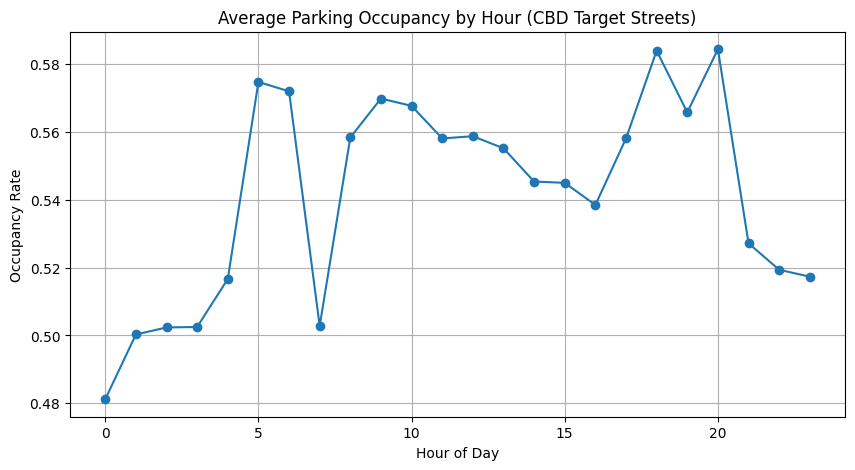


Top 10 Congestion Hotspots (by Street):
street_name
COLLINS STREET            0.566397
LITTLE BOURKE STREET      0.549975
LONSDALE STREET           0.546791
LITTLE COLLINS STREET     0.545289
LITTLE LONSDALE STREET    0.542440
ELIZABETH STREET          0.540844
BOURKE STREET             0.535977
Name: occupancy_binary, dtype: float64


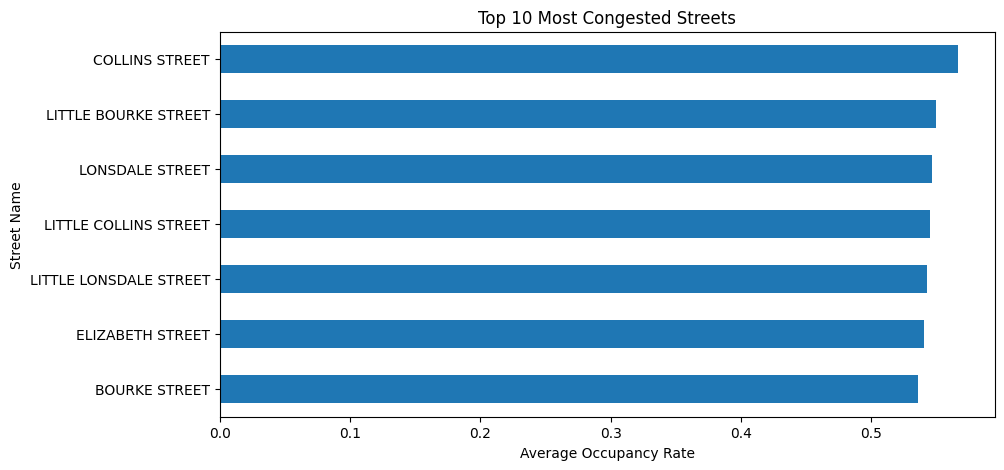

In [ ]:
# --- DEVELOPED BY: Atishay Jain ---
# Goal: Identify high-congestion 'hotspots' to provide strategic value to the City of Melbourne.

def analyse_parking_hotspots(df):
    """Visualising occupancy trends to identify peak demand periods."""

    df = df.copy()

    # Ensure occupancy is clean (safety reinforcement)
    df['occupancy_binary'] = df['occupancy_binary'].fillna(0)

    # 1. Peak Demand by Hour
    df['hour'] = df['arrival_time'].dt.hour
    hourly_occupancy = df.groupby('hour')['occupancy_binary'].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(hourly_occupancy.index, hourly_occupancy.values, marker='o')
    plt.title('Average Parking Occupancy by Hour (CBD Target Streets)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Occupancy Rate')
    plt.grid(True)
    plt.show()

    # 2. Hotspot Identification: Top Streets
    street_usage = (
        df.groupby('street_name')['occupancy_binary']
        .mean()
        .sort_values(ascending=False)
    )

    top_streets = street_usage.head(10)

    print("\nTop 10 Congestion Hotspots (by Street):")
    print(top_streets)

    # Visualise hotspots
    plt.figure(figsize=(10, 5))
    top_streets.sort_values().plot(kind='barh')
    plt.title('Top 10 Most Congested Streets')
    plt.xlabel('Average Occupancy Rate')
    plt.ylabel('Street Name')
    plt.show()

    return top_streets


# Execute Strategic EDA
hotspot_data = analyse_parking_hotspots(df_final)

## Interpretation of the Visualisation

The exploratory visualisations show that parking occupancy is not evenly distributed across the day or across streets. Instead, the data suggests that certain hours experience higher occupancy pressure, indicating stronger competition for available bays during those periods.

The street-level hotspot chart also shows that some CBD streets consistently have higher average occupancy than others. This tells us that parking demand is spatially concentrated rather than uniform across the city.

These findings are important because they confirm that:
- time-of-day is a meaningful predictor of parking behaviour,
- street location also influences occupancy patterns, and
- the dataset contains structured patterns that justify the use of predictive modelling.

In practical terms, this means that future parking guidance systems should not treat all locations or all times equally. Instead, they should account for both temporal and spatial demand differences.

## Step 5: Baseline Predictive Model Development

This step builds the first machine learning model for predicting parking bay occupancy.

The baseline model is designed to provide an initial forecasting benchmark rather than a final optimised solution. The purpose is to test whether a small set of structured features can already capture useful patterns in parking behaviour.

The model uses:
- **hour of day**,
- **day of week**, and
- **encoded bay identifier**

as input features. These features are chosen because they provide a simple but meaningful representation of temporal and location-based occupancy behaviour.

A **Random Forest Classifier** is used as the baseline algorithm because it is robust, handles nonlinear patterns well, and is suitable for structured tabular data.

In [5]:
# --- DEVELOPED BY: Yoginder Syal ---
# Goal: Build the technical pipeline for predictive forecasting.

def prepare_model_features(df):
    """Engineering features for supervised learning."""

    df = df.copy()

    # Ensure time features exist
    df['hour'] = df['arrival_time'].dt.hour
    df['day_of_week'] = df['arrival_time'].dt.dayofweek

    # Encode bay_id (categorical → numeric)
    le = LabelEncoder()
    df['bay_id_encoded'] = le.fit_transform(df['bay_id'])

    # Feature set (IMPROVED)
    features = ['bay_id_encoded', 'hour', 'day_of_week']

    X = df[features]
    y = df['occupancy_binary']

    return train_test_split(X, y, test_size=0.2, random_state=42)


def train_baseline_model(X_train, X_test, y_train, y_test):
    """Training a baseline Random Forest to predict bay availability."""

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print(f"\nBaseline Model Accuracy: {accuracy_score(y_test, predictions):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    return model


# Execute Technical Model Setup
X_train, X_test, y_train, y_test = prepare_model_features(df_final)
baseline_model = train_baseline_model(X_train, X_test, y_train, y_test)


Baseline Model Accuracy: 49.94%

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.23      0.30    222647
           1       0.53      0.72      0.61    270272

    accuracy                           0.50    492919
   macro avg       0.47      0.48      0.45    492919
weighted avg       0.47      0.50      0.47    492919



## Step 6: Technical Performance Evaluation

This step evaluates the baseline model using standard machine learning classification metrics.

Rather than relying only on raw accuracy, the notebook uses:
- **Precision**
- **Recall**
- **F1-Score**
- **Confusion Matrix**
- **Forecasting Variance**

These metrics are used because parking prediction quality cannot be judged by one number alone. A model can look acceptable overall but still make important mistakes in situations that affect drivers and urban traffic flow.

The confusion matrix is especially useful because it shows the exact balance of correct and incorrect classifications.


Sprint 3 Technical Performance Metrics
Precision: 0.5322
Recall: 0.7194
F1-Score: 0.6118


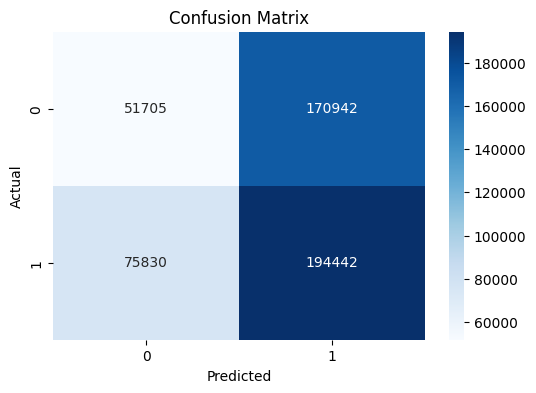

Forecasting Variance: 0.4634


In [6]:
# --- DEVELOPED BY: Yoginder Syal & Atishay Jain ---
# Goal: Evaluate the baseline model using Precision, Recall, F1-Score, Confusion Matrix, and forecasting variance review.

def evaluate_technical_performance(model, X_test, y_test):
    """Evaluating the predictive reliability of the baseline model."""

    predictions = model.predict(X_test)

    print("\nSprint 3 Technical Performance Metrics")
    print(f"Precision: {precision_score(y_test, predictions, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, predictions, zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, predictions, zero_division=0):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Mathematical review of forecasting variance
    variance = np.var(y_test - predictions)
    print(f"Forecasting Variance: {variance:.4f}")

    return predictions, cm, variance


# Execute Sprint 3 Technical Metrics
predictions, confusion_mat, forecast_variance = evaluate_technical_performance(
    baseline_model, X_test, y_test
)

## Interpretation of the Technical Results

The baseline model produced the following main performance scores:

- **Precision:** 0.5322  
- **Recall:** 0.7194  
- **F1-Score:** 0.6118  
- **Forecasting Variance:** 0.4634  

These results indicate that the model performs at a **moderate baseline level**. The recall score is higher than the precision score, which means the model is relatively better at identifying occupied bays than it is at making consistently accurate positive predictions.

The confusion matrix also shows that the model makes a substantial number of incorrect predictions. In particular, there are many cases where the model predicts a bay as occupied when it is not, and there are also a notable number of **false vacancy errors** where a bay is predicted as vacant when it is actually full.

This means the model is useful as an initial forecasting benchmark, but it is not yet reliable enough for real-world decision-making without further improvement. The results justify the need for later work such as feature engineering, model optimisation, and deeper error analysis.

## Step 7: Strategic Error Analysis

This step examines where and why the model fails.

While technical metrics show the overall quality of the model, they do not fully explain the **pattern of the errors**. For that reason, this section looks into model mistakes from a more strategic perspective.

The analysis focuses on:
- whether prediction errors are concentrated at certain **times of day**,
- whether certain **streets** have higher failure rates than others, and
- how many **false vacancy errors** occur, meaning cases where the model predicts a bay is vacant when it is actually occupied.

In real urban conditions, a false vacancy prediction can mislead drivers, increase search traffic, and reduce trust in the forecasting system.


Strategic Error Analysis Summary
Total prediction errors: 246772
False Vacancy errors (predicted vacant when actually full): 75830


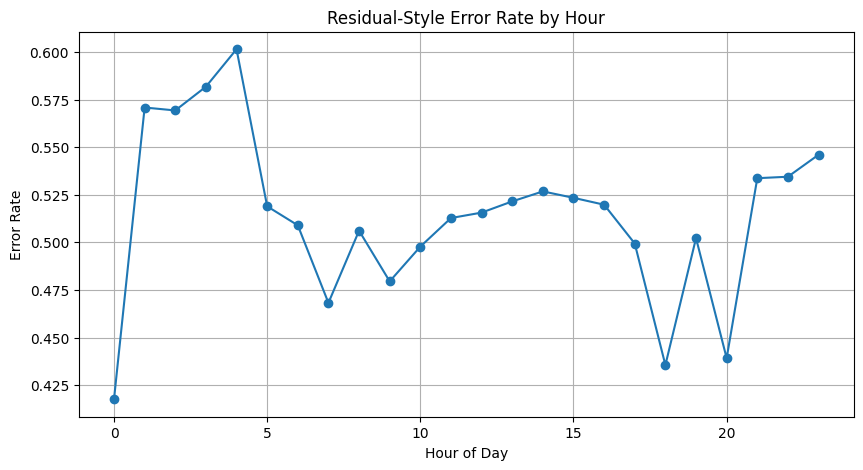

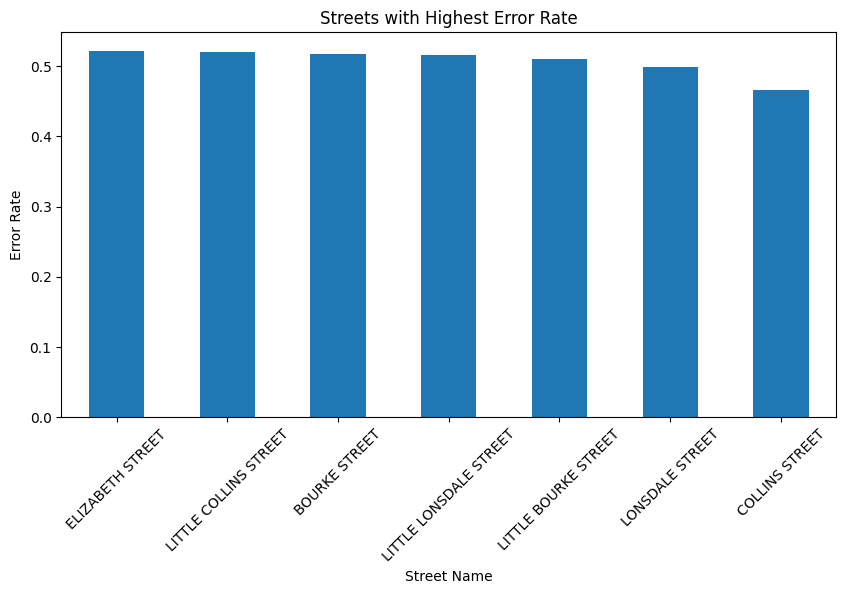

In [7]:
# --- DEVELOPED BY: Atishay Jain ---
# Goal: Analyse where the model fails and determine whether errors are caused by time-of-day variables or street-level factors, supporting stakeholder-facing strategic insight.

def strategic_error_analysis(df, X_test, y_test, predictions):
    """Analysing model failure patterns for stakeholder-ready interpretation."""

    error_df = df.loc[X_test.index].copy()
    error_df['actual'] = y_test.values
    error_df['predicted'] = predictions
    error_df['is_error'] = error_df['actual'] != error_df['predicted']

    # Time-of-day variable from timestamp
    error_df['hour'] = pd.to_datetime(error_df['arrival_time'], errors='coerce').dt.hour

    # False Positive = predicted vacant when actually full
    false_positives = error_df[
        (error_df['actual'] == 1) & (error_df['predicted'] == 0)
    ].copy()

    print("\nStrategic Error Analysis Summary")
    print(f"Total prediction errors: {error_df['is_error'].sum()}")
    print(f"False Vacancy errors (predicted vacant when actually full): {len(false_positives)}")

    # Error by hour
    error_by_hour = error_df.groupby('hour')['is_error'].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(error_by_hour.index, error_by_hour.values, marker='o')
    plt.title('Residual-Style Error Rate by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Error Rate')
    plt.grid(True)
    plt.show()

    # Error by street
    if 'street_name' in error_df.columns:
        error_by_street = error_df.groupby('street_name')['is_error'].mean().sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        error_by_street.plot(kind='bar')
        plt.title('Streets with Highest Error Rate')
        plt.xlabel('Street Name')
        plt.ylabel('Error Rate')
        plt.xticks(rotation=45)
        plt.show()

    return error_df, false_positives, error_by_hour


# Execute Strategic Error Analysis
error_df, false_positives, error_by_hour = strategic_error_analysis(
    df_final, X_test, y_test, predictions
)

## Interpretation of the Strategic Error Analysis

The strategic error analysis shows that the model’s mistakes are not random. Instead, error rates vary across both **time-of-day** and **street location**, which suggests that the current feature set does not fully capture all important parking dynamics.

The time-based error plot indicates that some hours experience noticeably higher error rates than others. This means parking behaviour changes across the day in ways that the baseline model cannot yet represent perfectly.

The street-level error plot shows that several major CBD streets, including **Elizabeth Street, Little Collins Street, Bourke Street, Little Lonsdale Street, and Little Bourke Street**, experience relatively high model error rates. This suggests that street-level context matters and may need to be modelled more explicitly in future versions.

A particularly important result is the number of **false vacancy errors (75,830)**. These are cases where the model predicts that a parking bay is vacant when it is actually occupied. From a stakeholder perspective, this is a high-impact error because it may direct drivers toward unavailable bays, increasing unnecessary circulation and reducing the practical usefulness of the system.

Overall, this analysis shows that the baseline model captures some broad occupancy structure, but still struggles with important location-specific and time-specific complexity.